In [1]:
import sys
import warnings

import polars as pl
from statsbombpy import sb

sys.dont_write_bytecode = True
warnings.filterwarnings("ignore")

In [2]:
from evaluation.eval import ModelEval
from feature_engineering.ColumnTransformer import ColumnTransformer
from feature_engineering.OpenFETransformations import OpenFETransformations
from feature_engineering.RowWiseTransformations import RowWiseTransformations
from training.nested_cv_eval import ModelCVEvaluator
from training.train import ModelTrainer
from training.tuning import ModelParamTuner
from utils.feature_engineering_handler import FeatureEngineeringHandler
from utils.inference_utils import (
    fetch_categorical_mapping_by_run_id,
    fetch_fitted_column_transformer_by_run_id,
    fetch_model,
    get_best_params_and_features_from_parent_run_id,
    get_ofe_feature_nodes_from_run_id,
    get_parent_run_id_from_experiment,
)
from utils.passes_handler import PassesHandler
from utils.preprocessing_handler import PreprocessingHandler
from utils.statics import (
    FINAL_MODELS_EXPERIMENT_ID,
    MODEL_SELECTION_EXPERIMENT_ID,
    NESTED_CV_EVAL_EXPERIMENT_ID,
    lightgbm_model_name,
)
from utils.utils import (
    compute_generalisation_error_from_run_id_and_experiment_id,
    plot_categorical_feature_distributions,
    plot_correlations,
    plot_mutual_information,
    plot_numerical_feature_distributions,
    plot_passes_by_predicted_probability,
    split_train_test,
)

model_type = lightgbm_model_name

# Modelling pass difficulties
I believe we can all agree that Pavard's half volley goal was a beautiful, but I the buildup to the goal is also really interesting to look into. Matuidi plays a through ball to Lucas Hernández who then plays a cross at a difficult angle back to Pavard, before he hits a half volley. While the half volley itself requires lots of technique (and luck), I want to answer the following about the passes:
1. Is there a way to quantify the difficulty of the two passes that lead up the goal (i.e. how likely are these types of passes to succeed?)
2. If yes, which pass was more difficult to make (has a lower probability of success)?

Fortunately, there are lots of data related to passes in the ``statsbombpy`` API which we can leverage to adopt a data-driven approach to answer our questions. The plan is to build a model that can tell us give us a pass difficulty score $p_\text{pass}$ for a pass from point $(x_1, y_1)$ to $(x_2, y_2)$ on the pitch. 

# Getting the data


In [3]:
wc2018_matches_df = sb.matches(competition_id=43, season_id=3).sort_values("match_date", ascending=False)
wc2018_matches = pl.from_pandas(wc2018_matches_df)
match_ids = wc2018_matches.select("match_id").to_series().to_list()

In [4]:
passes_handler = PassesHandler(match_ids=match_ids)
# passes_df = passes_handler.get_passes_from_match_ids()

Now that we have generated a .csv file, let us just simply load that.

In [5]:
passes_df = pl.read_parquet("../data/02-analysis/passes.parquet")

Let us now split the data into a train set and test set, so we only look at the training data.

In [6]:
train_df, test_df = split_train_test(passes_df=passes_df)

# Exploring the data
Let us take a quick look at the data and what each feature stands for according to the official [documentation](https://github.com/statsbomb/statsbombpy/blob/master/doc/Open%20Data%20Events%20v4.0.0.pdf):

- ``start_x``: x coordinate of the pass origin (where the pass started)
- ``start_y``: y coordinate of the pass origin
- ``end_x``: x coordinate of the pass destination (where the pass ended)
- ``end_y``: y coordinate of the pass destination
- ``length``: length of the pass in yards
- ``height``: the height type of the pass (e.g., Ground Pass, Low Pass, High Pass)
- ``angle``: angle of the pass in radians, with 0 pointing straight ahead. Values between 0 and $\pi$ indicating an angle clockwise, and negative values between 0 and $-\pi$ representing an angle anti-clockwise.
- ``duration``: the length the event lasted in seconds
- ``body_part``: which body part was used to make the pass (Head, Left foot, Right foot, Other)
- ``under_pressure``: Boolean indicating whether the player making the pass was under pressure by other players. Null if False.
- ``outcome``: result of the pass (e.g., Incomplete, Out, Pass offside, null if completed). This is our target variable.

There is also the ``match_id`` column, but we will not use that as an actual feature in our model. In regards to the coordinate system of the football pitch, the StatsBomb documentation defines the top left corner as the origin $(0,0)$ and the bottom right corner as $(120, 80)$ 

In [7]:
train_df.describe()

statistic,start_x,start_y,end_x,end_y,length,height,angle,duration,body_part,under_pressure,outcome
str,f64,f64,f64,f64,f64,str,f64,f64,str,f64,str
"""count""",61996.0,61996.0,61996.0,61996.0,61996.0,"""61996""",61996.0,61996.0,"""58803""",12894.0,"""12560"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,"""3193""",49102.0,"""49436"""
"""mean""",60.053229,40.37396,66.731934,40.198722,21.340367,null,0.026687,1.516974,null,1.0,null
"""std""",26.913721,24.038662,26.83367,23.802009,14.889273,null,1.559366,0.87322,null,null,null
"""min""",1.0,1.0,1.0,1.0,0.0,"""Ground Pass""",-3.120319,0.0,"""Drop Kick""",1.0,"""Incomplete"""
"""25%""",40.0,20.0,47.0,20.0,11.18034,null,-1.19029,0.947,null,null,null
"""50%""",59.0,40.0,66.0,40.0,17.464249,null,0.0,1.307,null,null,null
"""75%""",80.0,61.0,87.0,61.0,27.018513,null,1.2490457,1.84,null,null,null
"""max""",120.0,80.0,120.0,80.0,108.66922,"""Low Pass""",3.1415927,8.56,"""Right Foot""",1.0,"""Unknown"""


The ``null_count`` row tells us that the features ``body_part``, ``under_presssure`` and ``outcome`` have null values which will affect our choice of model.

In total, we have 10 features and the target variable. Out of the 10 features, 7 are continious, 2 are categorical and 1 is binary. Let us try to plot the correlation between the continious features.



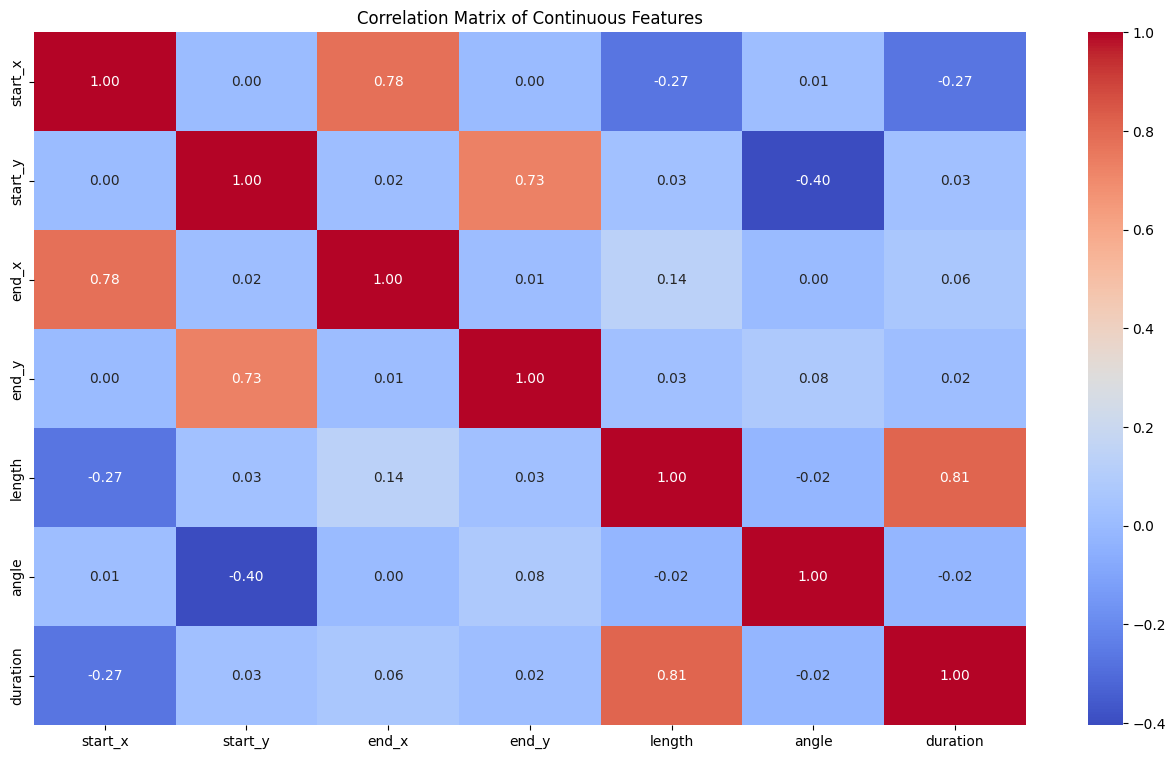

In [8]:
numerical_columns = [
    "start_x",
    "start_y",
    "end_x",
    "end_y",
    "length",
    "angle",
    "duration",
]

plot_correlations(
    train_df=train_df, numerical_cols=numerical_columns, fig_name="../../figures/analysis-02/feature_correlation.png"
)

From the matrix plot, we can observe that ``duration`` and ``length`` are highly positively correlated. There is also a high correlation between ``start_x`` and ``end_x`` and ``start_y`` and ``end_y``. There is also a significant inverse relationship ``start_x`` with ``length`` and ``duration`` and ``start_y`` and ``angle``. If we are considering using linar models, such as logistic regression, it is important to handle the multicollinearity.

Let us plot the distributions of the continuous features.

In [9]:
columns = train_df.columns
target_column = "outcome"
categorical_columns = [col for col in columns if col not in numerical_columns and col != target_column]

print("Number of categorical Columns:", len(categorical_columns))
print("Number of Numerical Columns:", len(numerical_columns))

Number of categorical Columns: 3
Number of Numerical Columns: 7


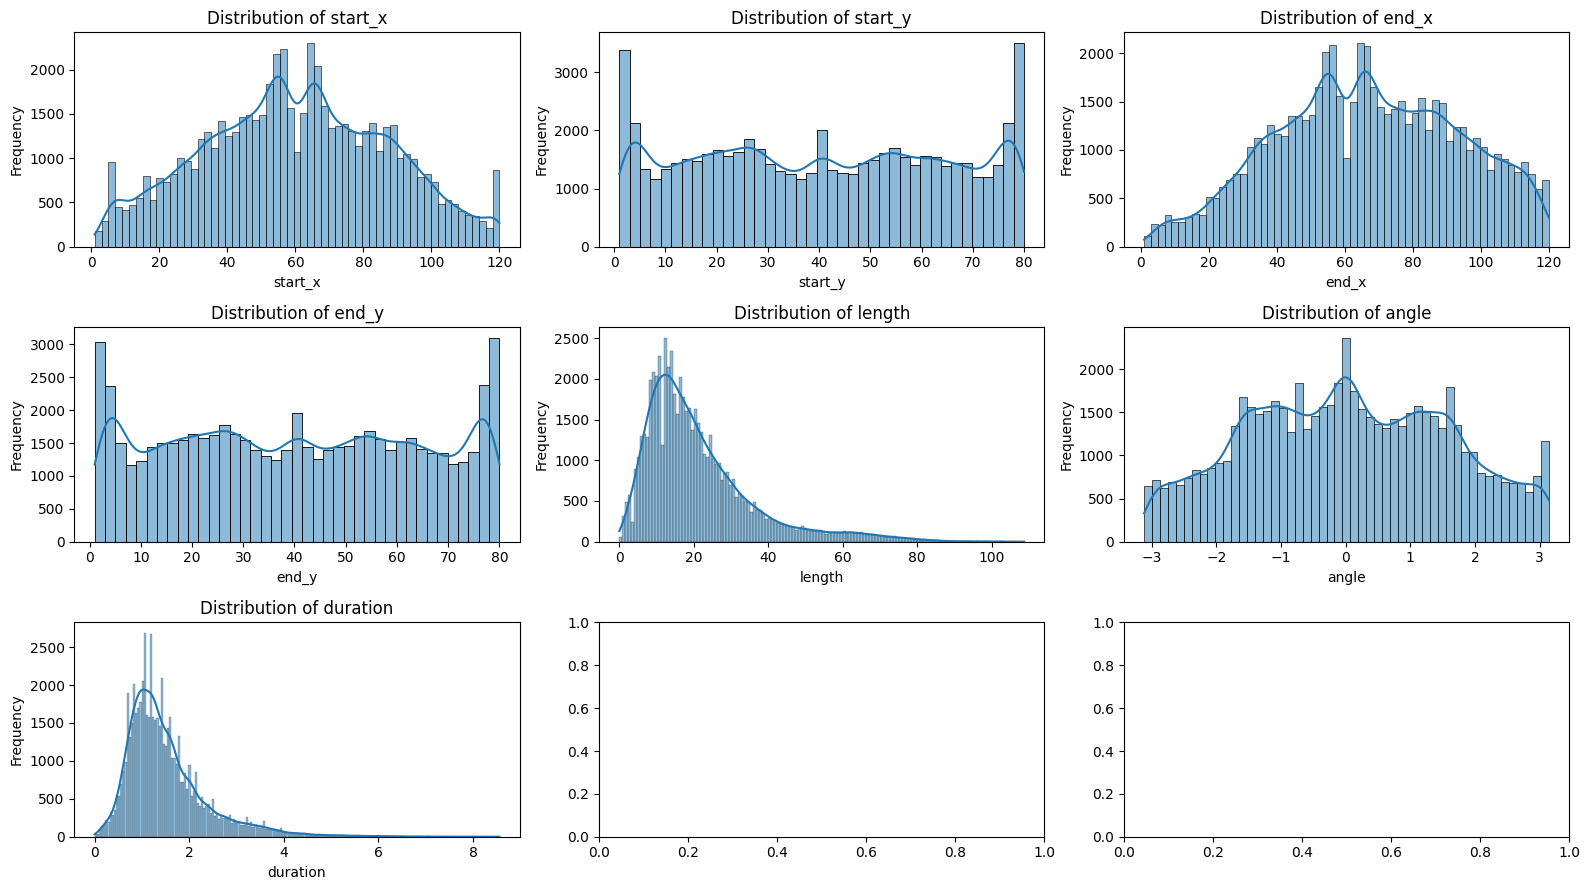

In [10]:
plot_numerical_feature_distributions(
    train_df=train_df,
    numerical_cols=numerical_columns,
    fig_name="../../figures/analysis-02/numerical_feature_distributions.png",
)

We can observe that the distributions for ``length`` and ``duration`` are right-skewed, resembling gamma distributions. The features ``start_x`` and ``end_x`` are approximately Gaussian distributed, while ``start_y``, ``end_y`` seems to follow some bi-modal distribution with high frequencies at the at both extremes near 0 and 80. The distribution for  ``angle``seems to follow a tri-modal distribution with the mode at 0.

Let us now try to visualise the frequencies for the categorical columns. Due to how the data is, we need to perform some simple preprocessing.
- ``body_part``: According to the documentation, the body part is only recorded for "most" passes, which means data is missing at random. We introduce the class "Unknown" for replace null values.
- ``under_pressure``: True equals true, and null equals false. We therefore set null = False
- ``outcome``: According to the documentation, passes missing an outcome are "Completed". We binary encode this variable, as we want to distinguish between "Completed" and "Incompleted".

Note that this preprocessing is tempoary for now, and we will perhaps do something else when training the model.

In [11]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
train_df_temp = preprocessing_handler.preprocess_outcome_column()
cat_columns = ["body_part", "height"]

2026-05-19 22:20:25,086 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-19 22:20:25,121 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-19 22:20:25,181 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-19 22:20:25,210 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


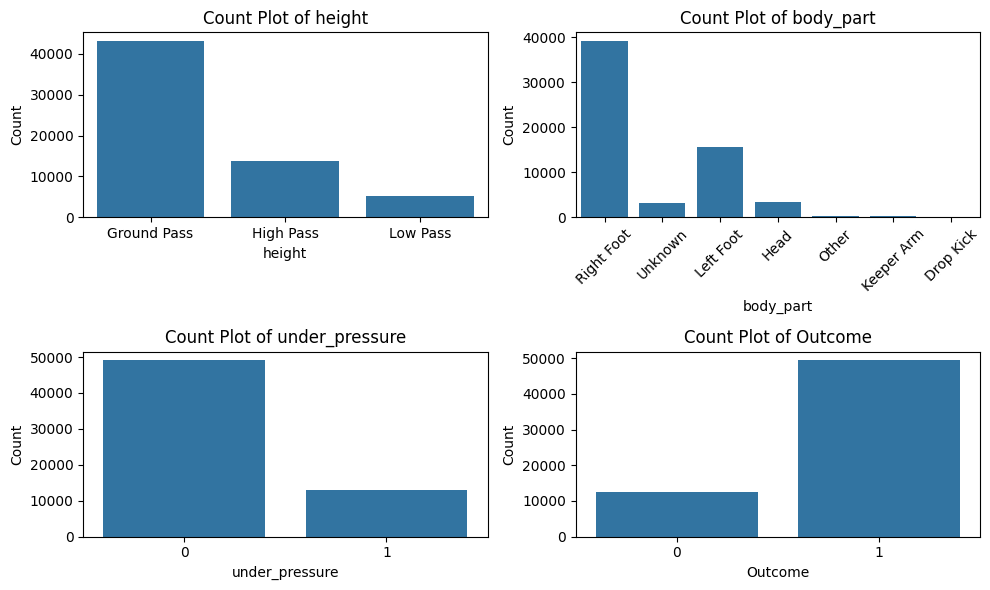

In [12]:
plot_categorical_feature_distributions(
    train_df=train_df_temp,
    categorical_cols=categorical_columns,
    fig_name="../../figures/analysis-02/categorical_feature_distributions.png",
)

Let us look at the percentages for the feature ``under_pressure`` and the target ``outcome``.

In [13]:
train_df_temp.select(
    pl.col("under_pressure").value_counts(normalize=True),
    pl.col("outcome").value_counts(normalize=True),
)

under_pressure,outcome
struct[2],struct[2]
"{1,0.207981}","{1,0.797406}"
"{0,0.792019}","{0,0.202594}"


We can observe that a large majority of passes were completed: Around 80% are completed with only 20% incompleted. Curiously, around 21% of the passes were made under pressure and 79% were not made under pressure. This is a pretty severe class imbalance for the target variable ``outcome`` which we will need to handle when splitting the dataset and perform stratified K-fold on the target variable ``outcome`` to ensure each fold contains the same proportions of completed and incompleted passes.

In [14]:
y_train = train_df_temp.select("outcome").to_series()
X_train_temp = train_df_temp.drop(pl.col("outcome"))

We can incorporate the categorical features as numerical values by using one-hot encoding for instance. Then we can compute the correlation matrix again.. 

In [15]:
feature_engineering_handler = FeatureEngineeringHandler(X=X_train_temp)
X_train = feature_engineering_handler.encode_columns(columns=["height", "body_part"])
# X_train = feature_engineering_handler.categorical_columns_to_int(columns=["height", "body_part"])

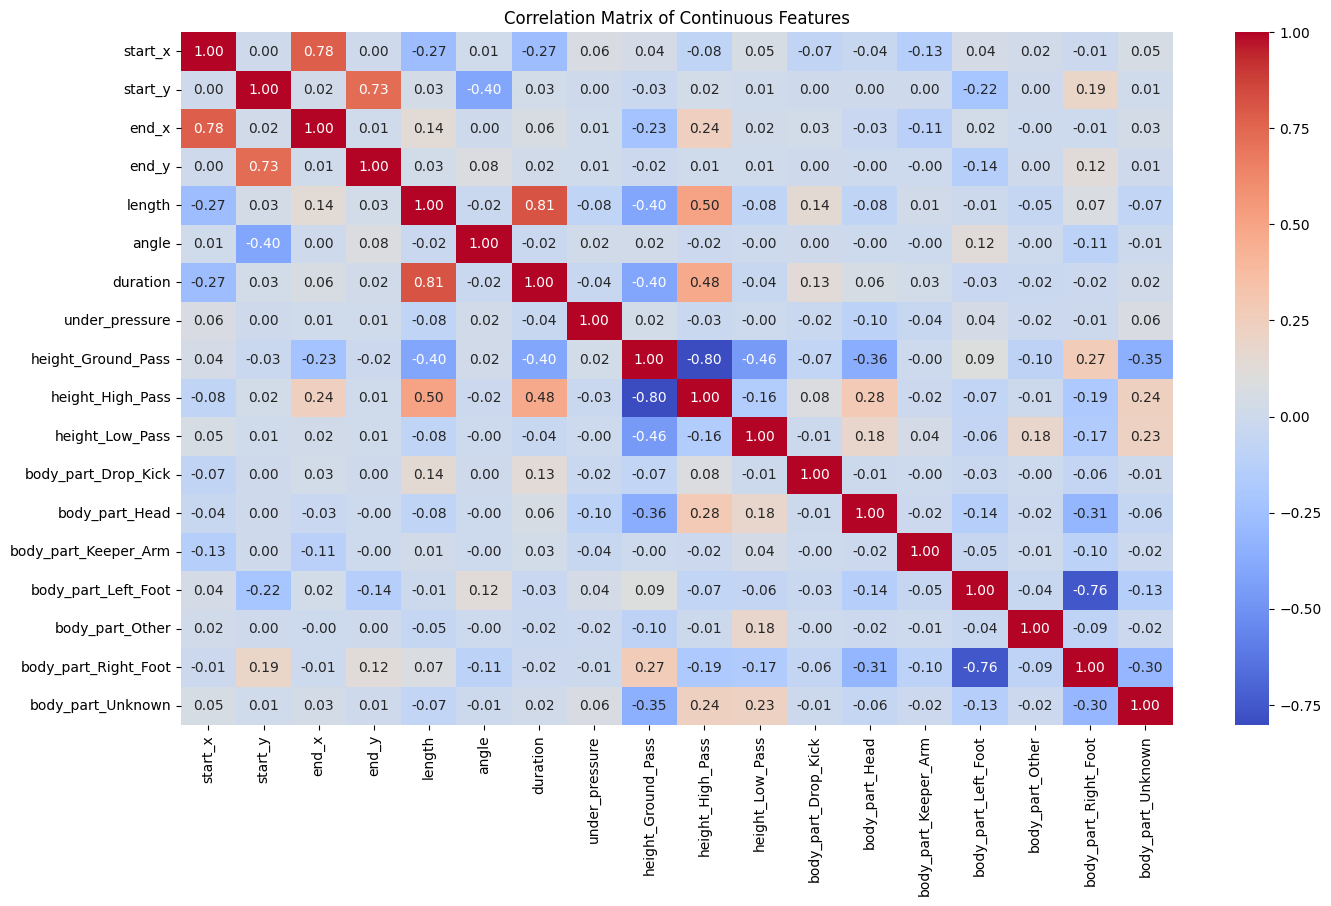

In [16]:
plot_correlations(
    train_df=X_train, numerical_cols=X_train.columns, fig_name="../../figures/analysis-02/feature_correlation_ohe.png"
)

Another thing we can try to do is compute the mutual information (MI) between all features and the target `outcome`. Unlike (Pearson's) correlation which only considers linear correlation between two features, the MI measures any kind of dependence between two random variables $X$ and $Y$. The MI is defined using the KL-divergence:
$$
I(X; Y) = \text{KL} (P_{XY} || P_X  P_Y)
$$

I use the `scikit-learn` implementation for discrete target variables [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html). 

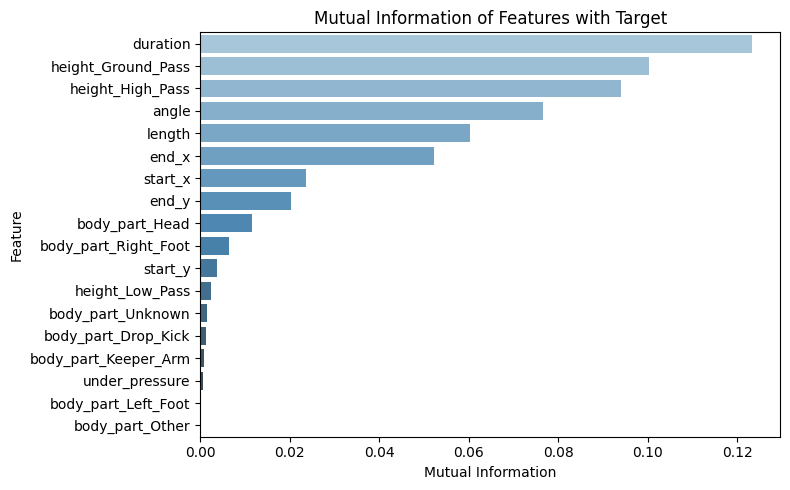

In [17]:
discrete_features = [False if col in numerical_columns else True for col in X_train.columns]
plot_mutual_information(X_train=X_train, y_train=y_train, discrete_features=discrete_features)

Ok, interesting. It seems the most important features contributing to the pass ``outcome`` is ``duration``, ``height``, ``angle`` and ``length``.  Among the coordinate features, ``end_x``, ``start_x``. ``end_y`` contribute much more to the mutual information than ``start_y``. In general the feature ``under_pressure`` and all ``body_part`` features contribute very little to the mutual information. 

It is important to stress that we compute the mutual information between each feature and the target as part of exploratory data analysis to quantify their statistical dependence, including nonlinear relationships. This analysis is model-agnostic and is used purely for feature understanding and preliminary assessment. We will select a loss function for our model later, which will align better with the questions we want to answer.

# Modelling choices

### Model
Based on the exploratory data analysis, I will opt for using a LGBM classifier as my base model. It is a tree-based gradient boosting model which has a number of advantages over linear classifiers. The LGBM classifer handles null values, is insensitive to feature scaling and performs implicit feature selection (by assigning unimportant features little influence). It also supports native handling of categorical variables (when specified), providing an alternative for one-hot encoding.

I could explore other classification models, such as logistic regression, random forest etc, but in my experience the LGBM classifier usually performs the best.

### Loss function
Given that I want to model the likelihood of completing a pass and not just a binary outcome (completed/failed), I have chosen to use NLL as the loss function. The NLL corresponds to maximising the likelihood given the model, encouraging well-calibrated probability estimates by heavily punishing overconfident incorrect predictions.

### Training specifications
Some other choices related to training the model:
- Validation strategy: I use the data from the Argentina - France as a holdout test set and use the data from all other matches as the training data. During model selection, the training data is splitted into a separate train and validation set using stratified K-fold to handle the class imbalance. 
- Hyperparameter tuning: I use `optuna` for hyperparameter tuning, because it is what I am familiar with. 
- Feature selection: LightGBM already has implicit feature selection, but I want to experiment with how other feature selection methods uch as RFE (recursive feature elimination) from `sklearn` (which work well with linear models) work in combination with GBT models. 
- MLOps: I will use MLFlow for experiment tracking and model registry.

### Evaluation specifications
I use the validation set to get an estimate of the model's ability to generalise to new data. I am particularly interested in training the model to have high accuracy and output well-calibrated uncertainty estimates. To evaluate the model, I use ROC-AUC curves, calibration plots and classification metrics such as NLL, F1, accuracy, recall, precision. 





# Training our first model
Let us train our first machine learning model to set a baseline. The training is as follows:
- Nested cross-validation where the inner loop is for hyperparameter tuning and feature selection, and outer loop is for model evaluation
- All training/evaluation is done using the cross-entropy loss function (also called log-loss for binary classificaiton)
- Hyperparameter tuning with Optuna
- Experiment logging in MLFlow

In [18]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [ ]:
cat_columns = ["body_part", "height"]

In [ ]:
row_wise_transformations = None
column_wise_transformations = None
open_fe_transformations = None

In [ ]:
run_name = "baseline_nested_cv_evaluation_native_categorical"
experiment_name = "Model evaluation with nested CV"
model_cv_evaluator = ModelCVEvaluator(
    model_type=model_type,
    row_wise_transformations=row_wise_transformations,
    column_wise_transformations=column_wise_transformations,
    open_fe_transformations=open_fe_transformations,
    n_inner_splits=5,
    n_outer_splits=5,
    n_trials=100,
    use_hyperparameter_tuning=False,
    use_feature_selection=False,
    use_feature_engineering=False,
    use_ofe=False,
    log_feature_importance=True,
    log_parameter_importance=True,
    run_name=run_name,
    experiment_name=experiment_name,
    categorical_columns=cat_columns,
)

In [ ]:
result_cv = model_cv_evaluator.get_generalisation_error(X_train=X_train, y_train=y_train)

2026-05-17 14:12:47,866 - INFO - Starting training with model catboost with the following configuration:
        - 5 inner splits
        - 5 outer splits
        - 100 trials
        - max 4 concurrent jobs
2026-05-17 14:12:48,438 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:12:48,438 - INFO - Fitting final model with best hyperparameters...
2026-05-17 14:14:03,929 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:14:03,929 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_1 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/c161d0041a2a495587a5870f61b33c0a
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:15:08,669 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:15:08,670 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_2 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/10498f1e62c648bd9fbd632c8dcac49b
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:16:14,262 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:16:14,262 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_3 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/34bbd2b048624ccc9b976f2ed4eb3b69
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:17:19,733 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:17:19,734 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_4 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/19482673c200486d963b93509d82ad9f
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


🏃 View run Outer_fold_5 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/4ef5bfd8899240b48528d8a3a97df250
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027
🏃 View run baseline_nested_cv_evaluation_native_categorical_catboost at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/694f3640de144f678a6475bd51e28509
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


In [23]:
parent_run_id = get_parent_run_id_from_experiment(
    result=result_cv, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID, model_type=model_type
)
compute_generalisation_error_from_run_id_and_experiment_id(
    parent_run_id=parent_run_id, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID
)

Number of outer folds: 5
95% confidence interval for best estimate of generalisation: 0.2648047839791555 ± 0.0017146327960872977


Ok, great. This is the benchmark we are trying to beat. Until now we have only used the "raw" features, such as length, but what if we added additional features such as length in the x-direction or average velocity of the pass? We are going to look into feature engineering to create better features that are hopefully easier for the model to learn from. 

# Feature engineering
Let us continue with some feature engineering phase where our goal is to make the data more "understandable" for our machine learning model. Feature engineering is an iterable process. I made a seperate notebook ``feature_engineering.ipynb`` and markdown file `FeatureEngineering.md` to keep track of my thought processes during the feature engineering stage. 


In [24]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [25]:
cat_columns = ["body_part", "height"]
column_transformer_config = {"cat_columns": cat_columns}

In [26]:
row_wise_transformations = RowWiseTransformations()
column_wise_transformations = ColumnTransformer(**column_transformer_config)
open_fe_transformations = None

In [27]:
run_name = "model_nested_cv_evaluation_native_categorical_feature_engineering"
experiment_name = "Model evaluation with nested CV"
model_cv_evaluator = ModelCVEvaluator(
    model_type=model_type,
    row_wise_transformations=row_wise_transformations,
    column_wise_transformations=column_wise_transformations,
    open_fe_transformations=open_fe_transformations,
    n_inner_splits=5,
    n_outer_splits=5,
    n_trials=100,
    use_hyperparameter_tuning=False,
    use_feature_selection=False,
    use_feature_engineering=True,
    use_ofe=False,
    log_feature_importance=True,
    log_parameter_importance=True,
    run_name=run_name,
    experiment_name=experiment_name,
    categorical_columns=cat_columns,
)

In [28]:
result_cv = model_cv_evaluator.get_generalisation_error(X_train=X_train, y_train=y_train)

2026-05-17 14:18:33,558 - INFO - Starting training with model catboost with the following configuration:
        - 5 inner splits
        - 5 outer splits
        - 100 trials
        - max 4 concurrent jobs
2026-05-17 14:18:33,819 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:18:33,820 - INFO - Fitting final model with best hyperparameters...
2026-05-17 14:19:42,320 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:19:42,320 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_1 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/1876a2721c0b4665a4c7dff9aacb3315
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:20:54,947 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:20:54,947 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_2 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/18f83a19b91c49fda326a7b8f3847bfb
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:22:08,531 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:22:08,531 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_3 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/3b3e9de27a3b4a9e8dbf895e1c29f3c1
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:23:22,724 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:23:22,725 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_4 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/419f0a37d0594764bda1ab06af475fb4
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


🏃 View run Outer_fold_5 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/6439222606e443c8839bd9acaed4f10e
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027
🏃 View run model_nested_cv_evaluation_native_categorical_feature_engineering_catboost at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/ed6458604d2245ff96a947a4594e088b
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


In [29]:
parent_run_id = get_parent_run_id_from_experiment(
    result=result_cv, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID, model_type=model_type
)
compute_generalisation_error_from_run_id_and_experiment_id(
    parent_run_id=parent_run_id, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID
)

Number of outer folds: 5
95% confidence interval for best estimate of generalisation: 0.2654725808335109 ± 0.0015800953062625708


# OHE columns

In [30]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [31]:
ohe_columns = ["body_part", "height"]
column_transformer_config = {"ohe_columns": ohe_columns}

In [32]:
row_wise_transformations = RowWiseTransformations()
column_wise_transformations = ColumnTransformer(**column_transformer_config)
open_fe_transformations = None

In [33]:
run_name = "model_nested_cv_evaluation_ohe_feature_engineering"
experiment_name = "Model evaluation with nested CV"
model_cv_evaluator = ModelCVEvaluator(
    model_type=model_type,
    row_wise_transformations=row_wise_transformations,
    column_wise_transformations=column_wise_transformations,
    open_fe_transformations=open_fe_transformations,
    n_inner_splits=5,
    n_outer_splits=5,
    n_trials=100,
    use_hyperparameter_tuning=False,
    use_feature_selection=False,
    use_feature_engineering=True,
    use_ofe=False,
    log_feature_importance=True,
    log_parameter_importance=True,
    run_name=run_name,
    experiment_name=experiment_name,
    ohe_columns=ohe_columns,
)

In [34]:
result_cv = model_cv_evaluator.get_generalisation_error(X_train=X_train, y_train=y_train)

2026-05-17 14:24:44,773 - INFO - Starting training with model catboost with the following configuration:
        - 5 inner splits
        - 5 outer splits
        - 100 trials
        - max 4 concurrent jobs
2026-05-17 14:24:45,127 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:24:45,128 - INFO - Fitting final model with best hyperparameters...
2026-05-17 14:25:08,264 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:25:08,265 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_1 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/59278fcd64264d969f812152cfa5ba11
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:25:31,265 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:25:31,265 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_2 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/eec83c4ad138425ead22de522b23cc2e
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:25:54,179 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:25:54,179 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_3 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/7b64d8ab806643a9914e5ba8e1b80efd
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


2026-05-17 14:26:16,615 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:26:16,615 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_4 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/b39e881e840a42099c3a88f26f2f2f69
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


🏃 View run Outer_fold_5 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/4c57f95cf91147cca655d3db9d3fa5a9
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027
🏃 View run model_nested_cv_evaluation_ohe_feature_engineering_catboost at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/09b781303f854cbcbb787a81c3dce01c
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


In [35]:
parent_run_id = get_parent_run_id_from_experiment(
    result=result_cv, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID, model_type=model_type
)
compute_generalisation_error_from_run_id_and_experiment_id(
    parent_run_id=parent_run_id, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID
)

Number of outer folds: 5
95% confidence interval for best estimate of generalisation: 0.26559453785226717 ± 0.0016403370160512321


Doesn't really add anything. Let us just stay with the native categorical handling in LightGBM.

# Automated feature engineering with OFE
Our feature engineering process took a long time to execute and did not really yield features that led to a significant reduction in NLL. Instead, we will be looking at the OFE framework which automatically generates suitable features. 

OFE generates hundreds of feature using different operators and transformations:

- **Unary numerical operators**: absolute value, logarithm, square root, squaring, sigmoid, rounding, and residual transformations, applied to individual features to modify their distributions.

- **Binary numerical operators**: addition, subtraction, multiplication, division, as well as minimum and maximum functions, used to capture interactions between pairs of numerical features.

- **Categorical-to-numerical operators**: group-by aggregations such as minimum, maximum, mean, median, standard deviation, and rank, computed over numerical variables within categorical groups.

- **Categorical-to-categorical operators**: combining categorical features, computing frequencies of combined categories, and counting the number of unique values within groups.

- **Frequency-based operators**: encoding the frequency of categorical values to capture how often they appear in the dataset.

This process takes several minutes to complete, which is still considerably faster than our manual feature engineering approach. However, because it involves operators such as group-by aggregations and frequency-based transformations, applying it outside the inner loop of the nested cross-validation setup will introduce data leakage. At the same time, incorporating it directly into the inner loop is computationally too expensive. To address this, I have decided to generate OFE features only in the outer loop, using the corresponding outer-loop training set. Within this procedure, OFE internally splits the outer training data into separate training and validation subsets. The training subset is used to fit a tree-based model, while the validation subset is used to evaluate the usefulness of the generated features.

As a result, some data leakage is inevitably introduced in the inner loop during hyperparameter tuning. However, it is important to emphasise that the outer loop remains free from data leakage. However, we will deal with this later.

In [36]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [37]:
cat_columns = ["body_part", "height"]
column_transformer_config = {"cat_columns": cat_columns}

In [38]:
row_wise_transformations = RowWiseTransformations()
column_wise_transformations = ColumnTransformer(**column_transformer_config)
open_fe_transformations = OpenFETransformations(n_features=5)

In [39]:
run_name = "model_nested_cv_evaluation_native_categorical_feature_engineering_ofe_top5"
experiment_name = "Model evaluation with nested CV"
model_cv_evaluator = ModelCVEvaluator(
    model_type=model_type,
    row_wise_transformations=row_wise_transformations,
    column_wise_transformations=column_wise_transformations,
    open_fe_transformations=open_fe_transformations,
    n_inner_splits=5,
    n_outer_splits=5,
    n_trials=100,
    use_hyperparameter_tuning=False,
    use_feature_selection=False,
    use_feature_engineering=True,
    use_ofe=True,
    log_feature_importance=True,
    log_parameter_importance=True,
    run_name=run_name,
    experiment_name=experiment_name,
    categorical_columns=cat_columns,
)

In [40]:
result_cv = model_cv_evaluator.get_generalisation_error(X_train=X_train, y_train=y_train)

2026-05-17 14:26:46,750 - INFO - Starting training with model catboost with the following configuration:
        - 5 inner splits
        - 5 outer splits
        - 100 trials
        - max 4 concurrent jobs
2026-05-17 14:26:47,014 - INFO - Fitting OpenFE on fold 1


The number of candidate features is 1775
Start stage I selection.


100%|██████████| 16/16 [00:12<00:00,  1.28it/s]


500 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|██████████| 16/16 [00:39<00:00,  2.47s/it]


...

The number of remaining candidate features is 599
Start stage II selection.


100%|██████████| 16/16 [00:21<00:00,  1.36s/it]


Finish data processing.


2026-05-17 14:38:40,251 - INFO - Feature: autoFE_f_0           | Formula: min(length,duration)
2026-05-17 14:38:40,252 - INFO - Feature: autoFE_f_1           | Formula: (duration/log_velocity)
2026-05-17 14:38:40,253 - INFO - Feature: autoFE_f_2           | Formula: residual(duration)
2026-05-17 14:38:40,253 - INFO - Feature: autoFE_f_3           | Formula: min(duration,end_y)
2026-05-17 14:38:40,254 - INFO - Feature: ofe_col_1            | Formula: freq(duration)
2026-05-17 14:38:40,269 - INFO - Starting full hyperparameter tuning...
2026-05-17 14:38:40,270 - INFO - Fitting final model with best hyperparameters...


🏃 View run Outer_fold_5 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/a10e4990554948a9bcc33823b4398c45
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027
🏃 View run model_nested_cv_evaluation_native_categorical_feature_engineering_ofe_top5_catboost at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/e6ed01b7d625480189f6dd1563a97de5
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


In [41]:
parent_run_id = get_parent_run_id_from_experiment(
    result=result_cv, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID, model_type=model_type
)
compute_generalisation_error_from_run_id_and_experiment_id(
    parent_run_id=parent_run_id, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID
)

Number of outer folds: 5
95% confidence interval for best estimate of generalisation: 0.25061662319364797 ± 0.0021090156511818646


By just adding new features to our data, we managed to cut the NLL from 0.2673805716768819 ± 0.0015428917947523993 to 0.2496416122740162 ± 0.0020533033261848767.

So far we have only used the standard hyper parameters. I will now perform hyperparameter optimisation using `optuna` to automatically tune the hyperparameters for better model performance.

# Hyperparameter tuning

In [19]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [20]:
cat_columns = ["body_part", "height"]
column_transformer_config = {"cat_columns": cat_columns}

In [21]:
row_wise_transformations = RowWiseTransformations()
column_wise_transformations = ColumnTransformer(**column_transformer_config)
open_fe_transformations = OpenFETransformations(n_features=10)

In [22]:
run_name = "model_nested_cv_evaluation_native_categorical_feature_engineering_ofe_top10_with_hyperparameter_tuning"
experiment_name = "Model evaluation with nested CV"
model_cv_evaluator = ModelCVEvaluator(
    model_type=model_type,
    row_wise_transformations=row_wise_transformations,
    column_wise_transformations=column_wise_transformations,
    open_fe_transformations=open_fe_transformations,
    n_inner_splits=5,
    n_outer_splits=5,
    n_trials=100,
    use_hyperparameter_tuning=True,
    use_feature_selection=False,
    use_feature_engineering=True,
    use_ofe=True,
    log_feature_importance=True,
    log_parameter_importance=True,
    run_name=run_name,
    experiment_name=experiment_name,
    categorical_columns=cat_columns,
)

In [23]:
result_cv = model_cv_evaluator.get_generalisation_error(X_train=X_train, y_train=y_train)

2026-05-17 11:11:25,533 - INFO - Starting training with model catboost with the following configuration:
        - 5 inner splits
        - 5 outer splits
        - 100 trials
        - max 4 concurrent jobs
2026-05-17 11:11:26,604 - INFO - Fitting OpenFE on fold 1


The number of candidate features is 1775
Start stage I selection.


100%|██████████| 16/16 [00:11<00:00,  1.43it/s]


500 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|██████████| 16/16 [00:34<00:00,  2.14s/it]


...

The number of remaining candidate features is 599
Start stage II selection.


100%|██████████| 16/16 [00:22<00:00,  1.41s/it]


Finish data processing.


2026-05-17 12:54:22,843 - INFO - Feature: autoFE_f_0           | Formula: min(length,duration)
2026-05-17 12:54:22,844 - INFO - Feature: autoFE_f_1           | Formula: (duration/log_velocity)
2026-05-17 12:54:22,845 - INFO - Feature: autoFE_f_2           | Formula: residual(duration)
2026-05-17 12:54:22,845 - INFO - Feature: autoFE_f_3           | Formula: min(duration,end_y)
2026-05-17 12:54:22,846 - INFO - Feature: autoFE_f_4           | Formula: (duration+direction_to_goal_cos)
2026-05-17 12:54:22,846 - INFO - Feature: autoFE_f_5           | Formula: (start_x*direction_to_goal_cos)
2026-05-17 12:54:22,847 - INFO - Feature: autoFE_f_6           | Formula: min(start_x,duration)
2026-05-17 12:54:22,847 - INFO - Feature: ofe_col_1            | Formula: freq(duration)
2026-05-17 12:54:22,848 - INFO - Feature: ofe_col_2            | Formula: GroupByThenRank(duration,height)
2026-05-17 12:54:22,848 - INFO - Feature: ofe_col_3            | Formula: GroupByThenMedian(log_velocity,end_y)
202

🏃 View run Outer_fold_5 at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/6668ac8ffef64a3ea14509c4d2a7f964
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027
🏃 View run model_nested_cv_evaluation_native_categorical_feature_engineering_ofe_top10_with_hyperparameter_tuning_catboost at: http://127.0.0.1:8080/#/experiments/416632419703074027/runs/1f2fadd410734efbb22b00e1dfd1f3f9
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/416632419703074027


In [ ]:
parent_run_id = get_parent_run_id_from_experiment(
    result=result_cv, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID, model_type=model_type
)
compute_generalisation_error_from_run_id_and_experiment_id(
    parent_run_id=parent_run_id, experiment_id=NESTED_CV_EVAL_EXPERIMENT_ID
)

Number of outer folds: 5
95% confidence interval for best estimate of generalisation: 0.24678254273389583 ± 0.0037392292529549007


Great, we have reduced the NLL to 0.24558400254858154 ± 0.0030443414118267805 leveraging feature engineering and hyperparameter optimisation.

Now that we have an idea of the generalisation loss of our current setup, let us one outer fold to find the optimal hyperparameters and features.

# Find optimal hyperparameters on one fold

In [66]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [67]:
cat_columns = ["body_part", "height"]
column_transformer_config = {"cat_columns": cat_columns}

In [68]:
row_wise_transformations = RowWiseTransformations()
column_wise_transformations = ColumnTransformer(**column_transformer_config)
open_fe_transformations = OpenFETransformations(n_features=5)

In [69]:
run_name = "Model_1"
experiment_name = "Model selection and hyperparameter tuning"
model_param_tuner = ModelParamTuner(
    model_type=model_type,
    row_wise_transformations=row_wise_transformations,
    column_wise_transformations=column_wise_transformations,
    open_fe_transformations=open_fe_transformations,
    n_inner_splits=5,
    n_trials=100,
    use_hyperparameter_tuning=True,
    use_feature_selection=False,
    use_feature_engineering=True,
    use_ofe=True,
    log_feature_importance=True,
    log_parameter_importance=True,
    log_calibration_curve=True,
    run_name=run_name,
    experiment_name=experiment_name,
    categorical_columns=cat_columns,
)

In [70]:
result = model_param_tuner.tune_and_train(X=X_train, y=y_train)

2026-05-17 15:45:26,583 - INFO - Starting training with model catboost with the following configuration:
        - 5 inner splits
        - 100 trials
        - max 4 concurrent jobs
2026-05-17 15:45:26,813 - INFO - Fitting OpenFE on fold 1


The number of candidate features is 1775
Start stage I selection.


100%|██████████| 16/16 [00:14<00:00,  1.11it/s]


496 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|██████████| 16/16 [00:40<00:00,  2.50s/it]


The number of remaining candidate features is 453
Start stage II selection.


100%|██████████| 16/16 [00:10<00:00,  1.53it/s]


Finish data processing.


2026-05-17 15:46:43,652 - INFO - Feature: autoFE_f_0           | Formula: (duration+log_velocity)
2026-05-17 15:46:43,654 - INFO - Feature: autoFE_f_1           | Formula: min(end_x,duration)
2026-05-17 15:46:43,655 - INFO - Feature: autoFE_f_2           | Formula: residual(duration)
2026-05-17 15:46:43,657 - INFO - Feature: autoFE_f_3           | Formula: min(duration,end_y)
2026-05-17 15:46:43,659 - INFO - Feature: ofe_col_1            | Formula: freq(duration)
2026-05-17 15:46:43,664 - INFO - Starting full hyperparameter tuning...
Best trial: 2. Best value: 0.253791: 100%|██████████| 100/100 [31:32<00:00, 18.93s/it] 
2026-05-17 16:18:20,346 - INFO - Fitting final model with best hyperparameters...


🏃 View run Model_1_catboost at: http://127.0.0.1:8080/#/experiments/428168727943543105/runs/08af3c5933a24d88a6a114583e5a27a5
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/428168727943543105


# Training final model

In [34]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [35]:
result = None
parent_run_id = get_parent_run_id_from_experiment(
    result=result, experiment_id=MODEL_SELECTION_EXPERIMENT_ID, model_type=model_type
)

In [36]:
row_wise_features, column_wise_features = get_ofe_feature_nodes_from_run_id(run_id=parent_run_id)

In [37]:
best_params, best_features = get_best_params_and_features_from_parent_run_id(parent_run_id=parent_run_id)

In [38]:
model_trainer = ModelTrainer(
    model_type=model_type,
    params=best_params,
    features=best_features.tolist(),
    row_wise_features=row_wise_features,
    column_wise_features=column_wise_features,
    row_wise_transformations=RowWiseTransformations(),
    categorical_columns=cat_columns,
    run_name="Model_1",
    experiment_name="Final models",
)

In [39]:
model = model_trainer.train(X_train=X_train, y_train=y_train)

2026-05-17 20:57:14,970 - INFO - Starting training with model catboost with the following configuration:
        - Params: depth=4, iterations=453, learning_rate=0.10226349535769663, n_estimators_used=408, reg_lambda=0.07744796325764351
        - Features: start_x, start_y, end_x, end_y, length, height, angle, duration, body_part, under_pressure, log_velocity, angle_sin, angle_cos, start_distance_to_goal, end_distance_to_goal, progressive_distance, direction_to_goal, direction_to_goal_cos, duration_x_under_pressure, log_velocity_x_under_pressure, length_x_under_pressure, autoFE_f_0, autoFE_f_1, autoFE_f_2, autoFE_f_3, ofe_col_1
        - Row-wise OFE nodes: 4
        - Column-wise OFE nodes: 1
        - Row-wise transformations: enabled
        
Successfully registered model 'Final models_catboost'.
Created version '1' of model 'Final models_catboost'.


🏃 View run Model_1_catboost at: http://127.0.0.1:8080/#/experiments/441823692328196814/runs/5cdd025e33d44b70a8cdf39d94ddf483
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/441823692328196814


# Evaliation on France - Argentina game

In [18]:
preprocessing_handler = PreprocessingHandler(df=train_df, categorical_columns=categorical_columns)
train_df_temp = preprocessing_handler.preprocess_categorical_columns()
X_train = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [19]:
preprocessing_handler = PreprocessingHandler(df=test_df, categorical_columns=categorical_columns)
test_df_temp = preprocessing_handler.preprocess_categorical_columns()
test_df_temp = preprocessing_handler.preprocess_outcome_column()
y_test = test_df_temp.select("outcome").to_series()
X_test = preprocessing_handler.preprocess_outcome_column().drop(pl.col("outcome"))

In [20]:
result = None
final_model_run_id = get_parent_run_id_from_experiment(
    result=result, experiment_id=FINAL_MODELS_EXPERIMENT_ID, model_type=model_type
)
tuning_run_id = get_parent_run_id_from_experiment(
    result=result, experiment_id=MODEL_SELECTION_EXPERIMENT_ID, model_type=model_type
)

In [21]:
row_wise_features, column_wise_features = get_ofe_feature_nodes_from_run_id(run_id=tuning_run_id)
best_params, best_features = get_best_params_and_features_from_parent_run_id(parent_run_id=tuning_run_id)
categorical_mapping = fetch_categorical_mapping_by_run_id(run_id=final_model_run_id)

In [22]:
column_transformer = fetch_fitted_column_transformer_by_run_id(
    run_id=final_model_run_id, artifact_name="fitted_column_transformer.pkl"
)

In [23]:
model = fetch_model(model_type=model_type, alias="production")

Loading model 'Final models_lightgbm' alias 'production' (version 17)...


Loaded model from 'models:/Final models_lightgbm@production'.


In [24]:
evaluator = ModelEval(
    model=model,
    X_train=X_train,
    y_train=y_train,
    best_features=best_features,
    experiment_name="Evaluation",
    row_wise_features=row_wise_features,
    column_wise_features=column_wise_features,
    categorical_columns=cat_columns,
    categorical_mapping=categorical_mapping,
    fitted_column_transformer=column_transformer,
)

In [25]:
result = evaluator.eval(X_test=X_test, y_test=y_test)

2026-05-19 22:20:32,232 - INFO - Starting evaluation for LGBMClassifier with the following configuration:
2026-05-19 22:20:34,470 - INFO - Test ROC AUC=0.9322 | Train ROC AUC=0.9558 | Acc=0.9130 | Precision=0.9225 | Recall=0.9767 | F1=0.9488| Log Loss=0.2397


🏃 View run LGBMClassifier at: http://127.0.0.1:8080/#/experiments/220281539845020993/runs/72b53ae0e1b8465e9690f935a3045cc1
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/220281539845020993


# Visualisation

Let us start by visualising all passes and their "difficulty"

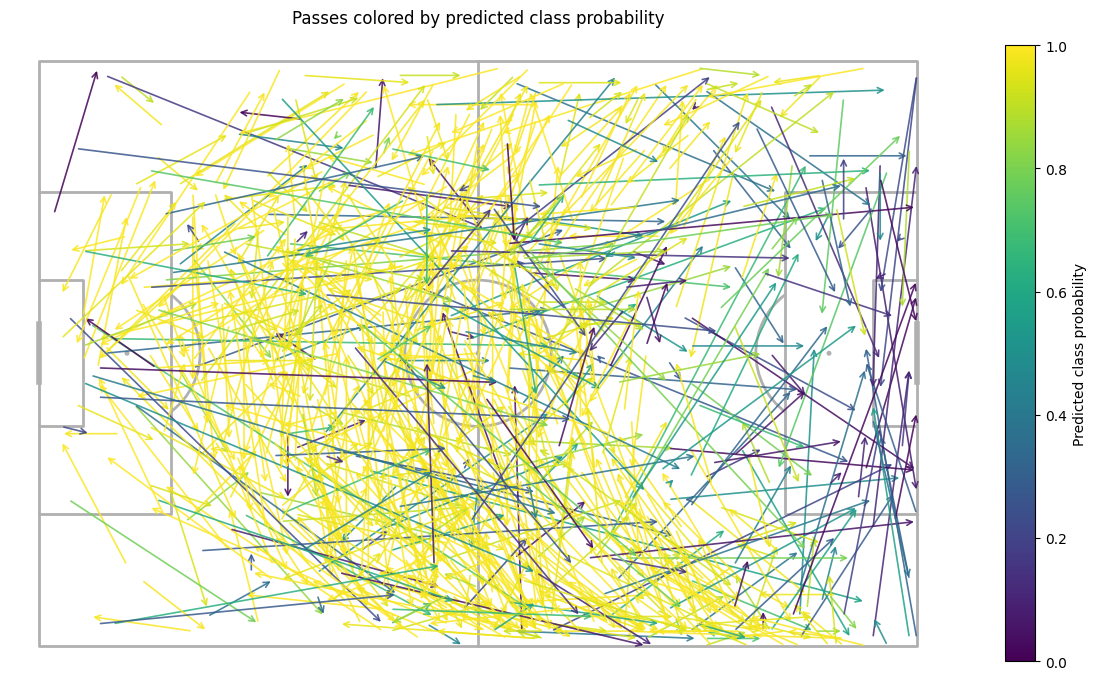

In [26]:
plot_passes_by_predicted_probability(result_df=result)

As we can observe from the figure, passes into the box are less likely to be successful. In fact, the closer a pass gets to the final third, the model assigns a lower probability to the pass. This makes a lot of sense. Possession-based ball circulation inherently means that a lot of passes before the final third are likely to be successful, whereas playing a pass into the final third is more likely to be rejected. 

The plot is overall pretty messy though, so let us now only look at the passes involved in the build-up to Pavard's goal. The events associated with the build-up have index 2195-2205 in the `statsbomb` event data for match ID 7580. 

Let us plot these passes.

In [31]:
filtered_results = result.filter(
    ((pl.col("start_x") == 63.0) & (pl.col("start_y") == 37.0))
    | ((pl.col("start_x") == 68.0) & (pl.col("start_y") == 17.0))
    | ((pl.col("start_x") == 116.0) & (pl.col("start_y") == 15.0))
)

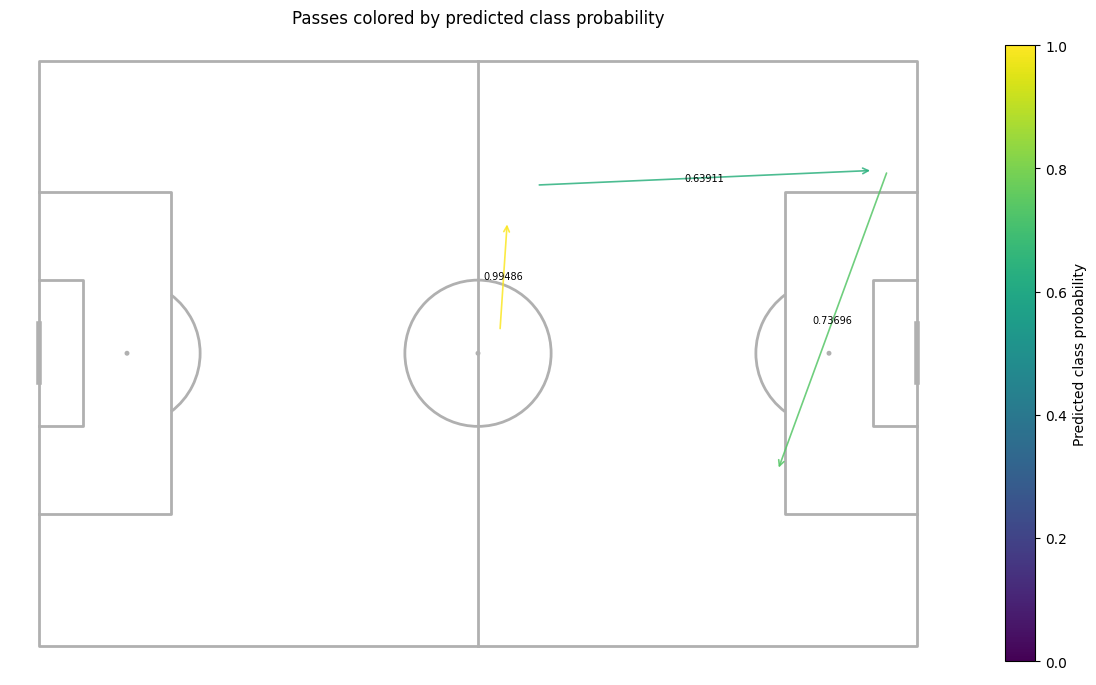

In [32]:
plot_passes_by_predicted_probability(
    result_df=filtered_results, name="passes_by_predicted_probability_buildup.png", show_probability=True
)

There are three passes in this sequence: Kante → Matuidi → Lucas Hernandez → Pavard. 

In a simplified world, we discard the impact of the carries to the overall sequence. With an expected goal (xG) of $0.02415$ for Pavard's shot, that means the probability of scoring from this sequence is:
$$
P(\text{goal} | \text{seq}) = 0.02415 \cdot 0.99486 \cdot 0.63911 \cdot 0.73696 = 0.0113
$$
Or 1.13% chance.


# Conclusion
In the beginning of this projects, we wanted to answer two questions: 

1. Is there a way to quantify the difficulty of the two passes that lead up the goal (i.e. how likely are these types of passes to succeed?)
2. If yes, which pass was more difficult to make (has a lower probability of success)?

With regard to the first question, I show that it is absolutely possible to quantify pass difficulty for the build-up to the goal. The model I trained functions basically as an xPass model, analogous to xG in shot evaluation.

For the second question, we refer back to the final plot. Although Lucas Hernández's cross is impressive, the model assigns it a higher probability of success than Blaise Matuidi’s through ball. Based on our model's estimates, Matuidi's pass is therefore considered the more difficult of the two.